# Precision Multi-Class Irrigation Intelligence

Reproducible training and model-selection notebook.

The task is to classify a crop field's `Irrigation_Need` as **Low**, **Medium** or **High**
from soil, weather, crop and field-management measurements.

This notebook runs the whole experiment end to end and writes three files:

| File | Contents |
|---|---|
| `irrigation_model.pkl` | the deployed pipeline: the training-fitted encoder plus the selected classifier |
| `model_schema.json` | raw feature order, categorical levels, numeric ranges and the class mapping |
| `experiments/results.json` | every number quoted in `README.md` and `MAIN.md` |

The code in these cells is the same code as `experiments/run_experiment.py`, so the notebook
and the headless script cannot drift apart.

**The order of operations matters and is deliberate.** The rows are split first, every
preprocessing step is fitted on the training split only, any imbalance handling touches the
training split only, model selection uses the validation split only, and the test split is
scored exactly once at the end.

## 1. Imports, configuration and random seed

In [1]:
import json
import os
import time
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from catboost import CatBoostClassifier
from imblearn.combine import SMOTETomek
from imblearn.over_sampling import SMOTE, SMOTENC, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from lightgbm import LGBMClassifier, early_stopping, log_evaluation
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

SEED = 42
NOISE_SEEDS = [42, 7, 2024, 13, 101]
TEST_SIZE = 0.15
VAL_SIZE = 0.15
EARLY_STOP_SIZE = 0.15
N_ESTIMATORS_CAP = 800
EARLY_STOPPING_ROUNDS = 50
CV_FOLDS = 5
CV_SUBSAMPLE = 150_000

BASE_DIR = os.path.dirname(os.path.abspath(os.getcwd()))
if not os.path.exists(os.path.join(BASE_DIR, "notebook", "train.csv")):
    BASE_DIR = os.path.abspath(os.getcwd())
DATA_PATH = os.path.join(BASE_DIR, "notebook", "train.csv")
OUT_DIR = os.path.join(BASE_DIR, "experiments")
TARGET = "Irrigation_Need"

# Ordered from fewest to most assumptions imposed on the training data. Used as the
# parsimony tie-break when several strategies are statistically indistinguishable.
STRATEGIES = [
    "none",
    "class_weight_balanced",
    "random_oversampling",
    "random_undersampling",
    "smote_on_encoded",
    "smote_original_partial",
    "smotenc_on_raw",
    "smotetomek_on_encoded",
]

np.random.seed(SEED)
results = {}


def log(message):
    print(f"[{time.strftime('%H:%M:%S')}] {message}", flush=True)


def evaluate(y_true, y_pred, y_proba, classes):
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=range(len(classes)), zero_division=0
    )
    metrics = {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "macro_precision": float(precision.mean()),
        "macro_recall": float(recall.mean()),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro")),
        "weighted_f1": float(f1_score(y_true, y_pred, average="weighted")),
        "per_class": {
            classes[i]: {
                "precision": float(precision[i]),
                "recall": float(recall[i]),
                "f1": float(f1[i]),
                "support": int(support[i]),
            }
            for i in range(len(classes))
        },
        "confusion_matrix": confusion_matrix(
            y_true, y_pred, labels=range(len(classes))
        ).tolist(),
    }
    if y_proba is not None:
        onehot = np.eye(len(classes))[np.asarray(y_true)]
        metrics["macro_roc_auc"] = float(
            roc_auc_score(y_true, y_proba, multi_class="ovr", average="macro")
        )
        metrics["macro_average_precision"] = float(
            average_precision_score(onehot, y_proba, average="macro")
        )
        metrics["micro_average_precision"] = float(
            average_precision_score(onehot, y_proba, average="micro")
        )
    return metrics

## 2. Dataset loading and data-quality audit

Before anything else: how many rows, which columns are categorical, are there missing values,
duplicate rows, or identical feature vectors carrying different labels?

In [2]:
# --------------------------------------------------------------- 1. load + audit
log("Loading dataset")
raw = pd.read_csv(DATA_PATH)
id_column_dropped = "id" in raw.columns
if id_column_dropped:
    raw = raw.drop(columns=["id"])

y_raw = raw[TARGET]
X_raw = raw.drop(columns=[TARGET])

CATEGORICAL = X_raw.select_dtypes(include="object").columns.tolist()
NUMERIC = [c for c in X_raw.columns if c not in CATEGORICAL]

label_encoder = LabelEncoder().fit(y_raw)
CLASSES = label_encoder.classes_.tolist()
y_all = pd.Series(label_encoder.transform(y_raw), index=X_raw.index)
HIGH_INDEX = CLASSES.index("High")

class_counts = y_raw.value_counts()
duplicate_features = int(X_raw.duplicated().sum())
contradictory = 0
if duplicate_features:
    dup_mask = X_raw.duplicated(keep=False)
    grouped = raw[dup_mask].groupby(list(X_raw.columns), observed=True)[TARGET].nunique()
    contradictory = int((grouped > 1).sum())

results["dataset"] = {
    "path": "notebook/train.csv",
    "rows": int(len(raw)),
    "n_features": int(X_raw.shape[1]),
    "id_column_dropped": id_column_dropped,
    "target": TARGET,
    "classes": CLASSES,
    "categorical_features": CATEGORICAL,
    "numeric_features": NUMERIC,
    "categorical_levels": {c: sorted(X_raw[c].unique().tolist()) for c in CATEGORICAL},
    "numeric_ranges": {
        c: {
            "min": float(X_raw[c].min()),
            "p25": float(X_raw[c].quantile(0.25)),
            "median": float(X_raw[c].median()),
            "p75": float(X_raw[c].quantile(0.75)),
            "max": float(X_raw[c].max()),
            "mean": float(X_raw[c].mean()),
            "std": float(X_raw[c].std()),
        }
        for c in NUMERIC
    },
    "missing_values_total": int(raw.isnull().sum().sum()),
    "duplicate_rows_including_target": int(raw.duplicated().sum()),
    "duplicate_rows_features_only": duplicate_features,
    "contradictory_label_groups": contradictory,
    "class_distribution": {
        cls: {
            "count": int(class_counts[cls]),
            "percentage": float(class_counts[cls] / len(raw) * 100),
        }
        for cls in CLASSES
    },
    "imbalance_ratio_majority_to_minority": float(class_counts.max() / class_counts.min()),
}

# class-conditional means, used to explain which features carry the signal
results["dataset"]["numeric_mean_by_class"] = {
    cls: {c: float(v) for c, v in raw[y_raw == cls][NUMERIC].mean().items()} for cls in CLASSES
}
results["dataset"]["categorical_class_share"] = {
    c: (pd.crosstab(raw[c], y_raw, normalize="index") * 100).round(3).to_dict("index")
    for c in CATEGORICAL
}

log(
    f"rows={len(raw)} classes={CLASSES} "
    f"imbalance={results['dataset']['imbalance_ratio_majority_to_minority']:.2f}"
)

[19:51:39] Loading dataset


[19:51:42] rows=630000 classes=['High', 'Low', 'Medium'] imbalance=17.61


## 3. Class distribution

,count,percentage
Low,369917,58.717
Medium,239074,37.948
High,21009,3.335


Imbalance ratio (majority to minority): 17.61


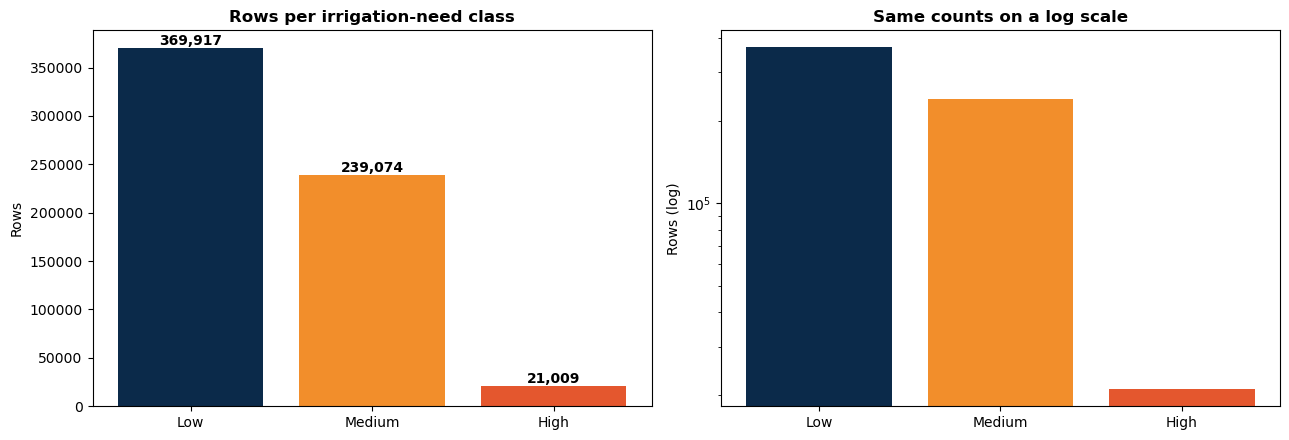

In [3]:
counts = pd.Series(
    {c: results["dataset"]["class_distribution"][c]["count"] for c in CLASSES}
).sort_values(ascending=False)

summary = pd.DataFrame({
    "count": counts,
    "percentage": (counts / counts.sum() * 100).round(3),
})
display(summary)
print("Imbalance ratio (majority to minority):",
      round(results["dataset"]["imbalance_ratio_majority_to_minority"], 2))

figure, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].bar(counts.index, counts.values, color=["#0B2A4A", "#F28E2B", "#E4572E"])
for index, value in enumerate(counts.values):
    axes[0].text(index, value, f"{value:,}", ha="center", va="bottom", fontweight="bold")
axes[0].set_title("Rows per irrigation-need class", fontweight="bold")
axes[0].set_ylabel("Rows")

axes[1].bar(counts.index, counts.values, color=["#0B2A4A", "#F28E2B", "#E4572E"])
axes[1].set_yscale("log")
axes[1].set_title("Same counts on a log scale", fontweight="bold")
axes[1].set_ylabel("Rows (log)")

plt.tight_layout()
plt.show()

### Which measurements actually separate the classes

Class-conditional averages for the numeric columns, and the class mix inside each level of the
categorical columns. This is what makes the later feature-importance ranking interpretable
rather than a black box.

,High,Low,Medium
Soil_pH,6.578,6.488,6.466
Soil_Moisture,17.670,43.306,29.744
Organic_Carbon,0.924,0.921,0.926
Electrical_Conductivity,1.691,1.732,1.769
Temperature_C,34.568,25.348,28.887
Humidity,61.120,61.949,61.005
Rainfall_mm,989.157,1500.534,1444.475
Sunlight_Hours,7.463,7.511,7.521
Wind_Speed_kmh,14.643,9.216,11.794
Field_Area_hectare,7.530,7.447,7.626


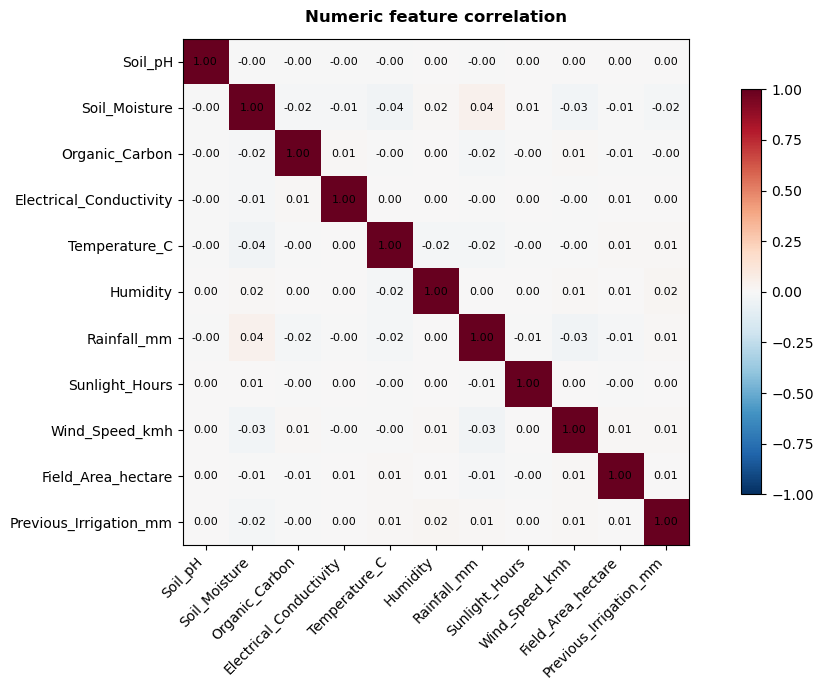


Class mix within Crop_Growth_Stage (row percentages):


,High,Low,Medium
Flowering,6.44,30.60,62.96
Harvest,0.32,84.79,14.89
Sowing,0.16,87.18,12.65
Vegetative,6.41,32.38,61.21



Class mix within Mulching_Used (row percentages):


,High,Low,Medium
No,5.85,44.50,49.64
Yes,0.79,73.06,26.14


In [4]:
means = pd.DataFrame(results["dataset"]["numeric_mean_by_class"]).round(3)
display(means)

figure, axes = plt.subplots(figsize=(11, 7))
correlation = X_raw[NUMERIC].corr()
im = axes.imshow(correlation, cmap="RdBu_r", vmin=-1, vmax=1)
axes.set_xticks(range(len(NUMERIC)))
axes.set_xticklabels(NUMERIC, rotation=45, ha="right")
axes.set_yticks(range(len(NUMERIC)))
axes.set_yticklabels(NUMERIC)
for i in range(len(NUMERIC)):
    for j in range(len(NUMERIC)):
        axes.text(j, i, f"{correlation.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
axes.set_title("Numeric feature correlation", fontweight="bold", pad=12)
figure.colorbar(im, shrink=0.8)
plt.tight_layout()
plt.show()

for column in ["Crop_Growth_Stage", "Mulching_Used"]:
    print(f"\nClass mix within {column} (row percentages):")
    display(pd.DataFrame(results["dataset"]["categorical_class_share"][column]).T.round(2))

## 4. Train / validation / test split

The split happens on the **raw** rows, before encoding and before any resampling. Doing it in
this order is what keeps the test split honest: nothing fitted later has seen it.

- **Training** teaches the model.
- **Validation** compares models and settings.
- **Test** is opened once, at the very end, to estimate performance on unseen fields.

In [5]:
# --------------------------------------------------------------- 2. split
log("Splitting raw rows 70/15/15 (stratified) before any preprocessing")
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_raw, y_all, test_size=TEST_SIZE, stratify=y_all, random_state=SEED
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval,
    y_trainval,
    test_size=VAL_SIZE / (1.0 - TEST_SIZE),
    stratify=y_trainval,
    random_state=SEED,
)

overlap_train_val = len(set(X_train.index) & set(X_val.index))
overlap_train_test = len(set(X_train.index) & set(X_test.index))
overlap_val_test = len(set(X_val.index) & set(X_test.index))
assert overlap_train_val == overlap_train_test == overlap_val_test == 0

results["split"] = {
    "strategy": "stratified random split of raw rows, performed before any encoding or resampling",
    "random_seed": SEED,
    "train_rows": int(len(X_train)),
    "val_rows": int(len(X_val)),
    "test_rows": int(len(X_test)),
    "train_pct": round(len(X_train) / len(raw) * 100, 2),
    "val_pct": round(len(X_val) / len(raw) * 100, 2),
    "test_pct": round(len(X_test) / len(raw) * 100, 2),
    "index_overlap_train_val": overlap_train_val,
    "index_overlap_train_test": overlap_train_test,
    "index_overlap_val_test": overlap_val_test,
    "class_counts": {
        "train": {CLASSES[k]: int(v) for k, v in y_train.value_counts().items()},
        "validation": {CLASSES[k]: int(v) for k, v in y_val.value_counts().items()},
        "test": {CLASSES[k]: int(v) for k, v in y_test.value_counts().items()},
    },
}
log(f"train={len(X_train)} val={len(X_val)} test={len(X_test)}")

[19:51:42] Splitting raw rows 70/15/15 (stratified) before any preprocessing


[19:51:43] train=441000 val=94500 test=94500


In [6]:
display(pd.DataFrame(results["split"]["class_counts"]))
print("Proportions per split:")
display(pd.DataFrame(results["split"]["class_counts"]).apply(lambda s: (s / s.sum() * 100).round(3)))

,train,validation,test
Low,258941,55488,55488
Medium,167352,35861,35861
High,14707,3151,3151


Proportions per split:


,train,validation,test
Low,58.717,58.717,58.717
Medium,37.948,37.948,37.948
High,3.335,3.334,3.334


## 5. Preprocessing, fitted on the training split only

Categorical columns are one-hot encoded with an encoder fitted on training rows only, so the
categories the model knows about come from training data alone and an unseen category at
serving time is handled instead of crashing.

Numeric columns are left unscaled for the tree ensembles, which are invariant to monotonic
rescaling. The linear baseline gets a `StandardScaler` inside its own pipeline because it
genuinely needs comparable scales to converge. That is a requirement of the algorithm, not an
advantage handed to it.

In [7]:
# --------------------------------------------- 3. preprocessing fitted on train only
def make_preprocessor(scale_numeric=False):
    return ColumnTransformer(
        [
            (
                "cat",
                OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=False),
                CATEGORICAL,
            ),
            ("num", StandardScaler() if scale_numeric else "passthrough", NUMERIC),
        ]
    )


tree_preprocessor = make_preprocessor().fit(X_train)
FEATURE_NAMES = [n.split("__", 1)[1] for n in tree_preprocessor.get_feature_names_out()]
Xt_train = tree_preprocessor.transform(X_train)
Xt_val = tree_preprocessor.transform(X_val)
Xt_test = tree_preprocessor.transform(X_test)

results["preprocessing"] = {
    "fitted_on": "training split only",
    "categorical_encoding": "OneHotEncoder(drop='first', handle_unknown='ignore')",
    "numeric_handling": (
        "passed through unscaled for the tree ensembles; StandardScaler applied inside the "
        "Logistic Regression pipeline only, because a linear model needs comparable scales to converge"
    ),
    "encoded_feature_count": int(Xt_train.shape[1]),
    "encoded_feature_names": FEATURE_NAMES,
}

## 6. Choosing how to handle the class imbalance

The High class is the rarest and the most costly to miss, so the imbalance has to be dealt with
deliberately rather than by habit. Eight strategies are compared under one fixed probe model,
one fixed split, and one fixed metric.

Two of them deserve particular attention:

- **Plain SMOTE on one-hot columns** is what the earlier version of this project used. It
  interpolates between neighbouring rows, which is defensible for a continuous column such as
  soil moisture but produces fractional values in one-hot columns, i.e. synthetic rows that are
  0.4 Loamy and 0.6 Sandy. No such field exists.
- **SMOTENC** is the variant designed for mixed numeric and categorical data: it interpolates
  the numeric columns and assigns each categorical column by a majority vote among the
  neighbours, so every synthetic row stays a valid field.

The selection rule is fixed in advance: take the best validation Macro F1, measure how much
that metric moves across seeds for reasons unrelated to the strategy, treat everything within
one standard deviation of the best as indistinguishable, and among those pick the strategy that
assumes the least.

In [8]:
# --------------------------------------------------------------- 4. imbalance study
PROBE_PARAMS = dict(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=63,
    min_child_samples=40,
    subsample=0.8,
    subsample_freq=1,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    n_jobs=-1,
    verbose=-1,
)


def apply_strategy(X_enc, y, strategy, seed, raw_frame=None, encoder=None):
    """Apply an imbalance strategy to an already-encoded training matrix.

    Returns (X, y, sample_weight). raw_frame/encoder are only needed by SMOTENC, which
    has to see the untouched categorical columns.
    """
    if strategy == "none":
        return X_enc, y, None

    if strategy == "class_weight_balanced":
        counts = np.bincount(y)
        return X_enc, y, (len(y) / (len(counts) * counts))[y]

    if strategy == "random_oversampling":
        Xr, yr = RandomOverSampler(random_state=seed).fit_resample(X_enc, y)
    elif strategy == "random_undersampling":
        Xr, yr = RandomUnderSampler(random_state=seed).fit_resample(X_enc, y)
    elif strategy == "smote_on_encoded":
        Xr, yr = SMOTE(random_state=seed, k_neighbors=5).fit_resample(X_enc, y)
    elif strategy == "smote_original_partial":
        counts = np.bincount(y)
        scale = len(y) / len(y_train)
        targets = {
            HIGH_INDEX: max(int(counts[HIGH_INDEX]), int(100_000 * scale)),
            CLASSES.index("Medium"): max(int(counts[CLASSES.index("Medium")]), int(200_000 * scale)),
        }
        Xr, yr = SMOTE(sampling_strategy=targets, random_state=seed, k_neighbors=5).fit_resample(X_enc, y)
    elif strategy == "smotenc_on_raw":
        Xr_df, yr = SMOTENC(
            categorical_features=CATEGORICAL, random_state=seed, k_neighbors=5
        ).fit_resample(raw_frame, y)
        Xr = encoder.transform(Xr_df)
    elif strategy == "smotetomek_on_encoded":
        Xr, yr = SMOTETomek(random_state=seed).fit_resample(X_enc, y)
    else:
        raise ValueError(strategy)
    return Xr, yr, None


def resample(strategy, seed=SEED):
    return apply_strategy(
        Xt_train, y_train.values, strategy, seed, raw_frame=X_train, encoder=tree_preprocessor
    )


STRATEGY_NOTES = {
    "none": "train on the observed distribution, no resampling and no reweighting",
    "class_weight_balanced": "no synthetic rows; each class weighted inversely to its frequency",
    "random_oversampling": "existing minority rows duplicated until every class matches the majority",
    "random_undersampling": "majority rows discarded until every class matches the minority",
    "smote_on_encoded": "plain SMOTE interpolating the one-hot columns, minority classes raised to majority size",
    "smote_original_partial": "the original project's partial SMOTE targets, also interpolating one-hot columns",
    "smotenc_on_raw": "SMOTENC on the raw frame: numeric columns interpolated, categorical columns set by neighbourhood majority vote",
    "smotetomek_on_encoded": "SMOTE followed by Tomek-link cleaning of borderline pairs",
}

log("Imbalance strategy study (probe model: LightGBM with fixed hyperparameters)")
strategy_results = {}
for strategy in STRATEGIES:
    start = time.time()
    try:
        Xr, yr, weights = resample(strategy)
        model = LGBMClassifier(random_state=SEED, **PROBE_PARAMS)
        model.fit(Xr, yr, sample_weight=weights)
        metrics = evaluate(y_val.values, model.predict(Xt_val), model.predict_proba(Xt_val), CLASSES)
    except Exception as error:  # noqa: BLE001
        log(f"  {strategy}: FAILED -> {error}")
        strategy_results[strategy] = {"status": "failed", "error": str(error)}
        continue

    strategy_results[strategy] = {
        "status": "ok",
        "note": STRATEGY_NOTES[strategy],
        "train_rows_after": int(len(yr)),
        "train_class_counts_after": {
            CLASSES[k]: int(v) for k, v in zip(*np.unique(yr, return_counts=True))
        },
        "validation": metrics,
        "seconds": round(time.time() - start, 1),
    }
    log(
        f"  {strategy:<24} rows={len(yr):>7} macroF1={metrics['macro_f1']:.4f} "
        f"acc={metrics['accuracy']:.4f} HighRecall={metrics['per_class']['High']['recall']:.4f} "
        f"HighF1={metrics['per_class']['High']['f1']:.4f}"
    )

ok = {k: v for k, v in strategy_results.items() if v.get("status") == "ok"}
top_macro = max(v["validation"]["macro_f1"] for v in ok.values())

# noise floor: repeat the two cheapest strategies across seeds to measure how much
# validation Macro F1 moves for reasons unrelated to the strategy itself
log("Run-to-run noise study")
noise = {}
for strategy in ("none", "smote_original_partial"):
    scores = []
    for seed in NOISE_SEEDS:
        Xr, yr, weights = resample(strategy, seed)
        model = LGBMClassifier(random_state=seed, **PROBE_PARAMS)
        model.fit(Xr, yr, sample_weight=weights)
        scores.append(float(f1_score(y_val.values, model.predict(Xt_val), average="macro")))
    noise[strategy] = {
        "seeds": NOISE_SEEDS,
        "macro_f1_scores": scores,
        "mean": float(np.mean(scores)),
        "std": float(np.std(scores, ddof=1)),
        "range": float(max(scores) - min(scores)),
    }
    log(f"  {strategy:<24} mean={np.mean(scores):.4f} std={np.std(scores, ddof=1):.4f}")

NOISE_STD = max(v["std"] for v in noise.values())
threshold = top_macro - NOISE_STD
indistinguishable = [
    s for s in STRATEGIES if s in ok and ok[s]["validation"]["macro_f1"] >= threshold
]
BEST_STRATEGY = indistinguishable[0]

results["imbalance_study"] = {
    "probe_model": "LightGBM with fixed hyperparameters, trained on the training split and scored on validation",
    "probe_hyperparameters": PROBE_PARAMS,
    "assumption_order": STRATEGIES,
    "selection_rule": (
        "Take the best validation Macro F1. Estimate the run-to-run standard deviation of that metric "
        "by repeating the probe across five seeds. Every strategy within one standard deviation of the "
        "best is treated as statistically indistinguishable, and among those the strategy that imposes "
        "the fewest assumptions on the training data is selected."
    ),
    "strategies": strategy_results,
    "noise_study": noise,
    "noise_std_used": NOISE_STD,
    "best_validation_macro_f1": top_macro,
    "indistinguishable_threshold": threshold,
    "indistinguishable_strategies": indistinguishable,
    "selected": BEST_STRATEGY,
}
log(f"Selected imbalance strategy: {BEST_STRATEGY}")

Xr_train, yr_train, w_train = resample(BEST_STRATEGY)

[19:51:44] Imbalance strategy study (probe model: LightGBM with fixed hyperparameters)


[19:52:05]   none                     rows= 441000 macroF1=0.9703 acc=0.9844 HighRecall=0.9146 HighF1=0.9415


[19:52:27]   class_weight_balanced    rows= 441000 macroF1=0.9640 acc=0.9830 HighRecall=0.9378 HighF1=0.9249


[19:52:52]   random_oversampling      rows= 776823 macroF1=0.9676 acc=0.9844 HighRecall=0.9410 HighF1=0.9328


[19:53:08]   random_undersampling     rows=  44121 macroF1=0.9478 acc=0.9794 HighRecall=0.9559 HighF1=0.8813


...

[20:14:00]   smotetomek_on_encoded    rows= 747895 macroF1=0.9698 acc=0.9843 HighRecall=0.9203 HighF1=0.9400


[20:14:00] Run-to-run noise study


[20:15:37]   none                     mean=0.9703 std=0.0003


[20:18:33]   smote_original_partial   mean=0.9707 std=0.0004


[20:18:33] Selected imbalance strategy: smote_original_partial


,rows after,macro F1,accuracy,High precision,High recall,High F1
none,441000.0,0.9703,0.9844,0.9700,0.9146,0.9415
class_weight_balanced,441000.0,0.9640,0.9830,0.9123,0.9378,0.9249
random_oversampling,776823.0,0.9676,0.9844,0.9248,0.9410,0.9328
random_undersampling,44121.0,0.9478,0.9794,0.8176,0.9559,0.8813
smote_on_encoded,776823.0,0.9702,0.9845,0.9625,0.9207,0.9411
smote_original_partial,558941.0,0.9709,0.9846,0.9667,0.9207,0.9431
smotenc_on_raw,776823.0,0.9636,0.9826,0.9156,0.9330,0.9242
smotetomek_on_encoded,747895.0,0.9698,0.9843,0.9606,0.9203,0.9400


Run-to-run standard deviation of validation Macro F1: 0.0004
Best validation Macro F1: 0.9709
Indistinguishable from the best: ['smote_original_partial']
Selected: smote_original_partial


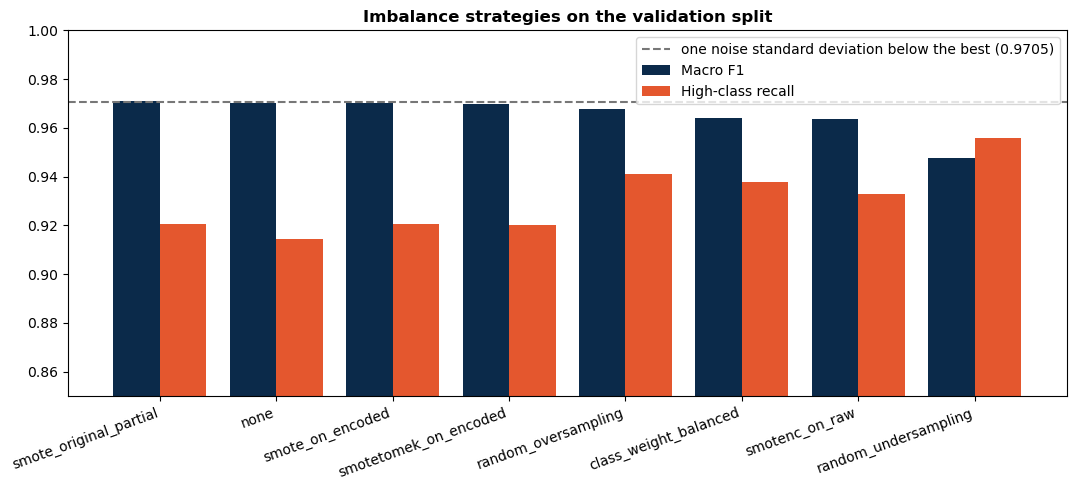

In [9]:
table = pd.DataFrame({
    name: {
        "rows after": entry["train_rows_after"],
        "macro F1": round(entry["validation"]["macro_f1"], 4),
        "accuracy": round(entry["validation"]["accuracy"], 4),
        "High precision": round(entry["validation"]["per_class"]["High"]["precision"], 4),
        "High recall": round(entry["validation"]["per_class"]["High"]["recall"], 4),
        "High F1": round(entry["validation"]["per_class"]["High"]["f1"], 4),
    }
    for name, entry in strategy_results.items()
    if entry.get("status") == "ok"
}).T
display(table)

print(f"Run-to-run standard deviation of validation Macro F1: {NOISE_STD:.4f}")
print(f"Best validation Macro F1: {top_macro:.4f}")
print(f"Indistinguishable from the best: {indistinguishable}")
print(f"Selected: {BEST_STRATEGY}")

figure, axes = plt.subplots(figsize=(11, 5))
order = table.sort_values("macro F1", ascending=False)
positions = np.arange(len(order))
axes.bar(positions - 0.2, order["macro F1"], 0.4, label="Macro F1", color="#0B2A4A")
axes.bar(positions + 0.2, order["High recall"], 0.4, label="High-class recall", color="#E4572E")
axes.axhline(threshold, ls="--", color="#777777",
             label=f"one noise standard deviation below the best ({threshold:.4f})")
axes.set_xticks(positions)
axes.set_xticklabels(order.index, rotation=20, ha="right")
axes.set_ylim(0.85, 1.0)
axes.set_title("Imbalance strategies on the validation split", fontweight="bold")
axes.legend()
plt.tight_layout()
plt.show()

## 7. Training the candidate models

Four models, one protocol. Each sees the same training rows, the same encoding and the same
imbalance strategy.

Early stopping runs against an inner slice carved out of the **training** split, not against
the validation split. That keeps validation clean: it is used only to compare finished models,
never to decide when one of them should stop.

In [10]:
# --------------------------------------------------------------- 5. candidates
log("Training candidates under an identical protocol")
fit_idx, stop_idx = train_test_split(
    np.arange(len(yr_train)), test_size=EARLY_STOP_SIZE, stratify=yr_train, random_state=SEED
)
Xf, Xs = Xr_train[fit_idx], Xr_train[stop_idx]
yf, ys = yr_train[fit_idx], yr_train[stop_idx]
wf = w_train[fit_idx] if w_train is not None else None
ws = w_train[stop_idx] if w_train is not None else None

XGB_PARAMS = dict(
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    gamma=0.1,
    reg_lambda=2.0,
    reg_alpha=0.1,
    objective="multi:softprob",
    random_state=SEED,
    n_jobs=-1,
    tree_method="hist",
)
LGBM_PARAMS = dict(
    learning_rate=0.05,
    num_leaves=63,
    min_child_samples=40,
    subsample=0.8,
    subsample_freq=1,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=SEED,
    n_jobs=-1,
    verbose=-1,
)
CAT_PARAMS = dict(
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=5,
    loss_function="MultiClass",
    random_seed=SEED,
    verbose=False,
    allow_writing_files=False,
)
LOGIT_PARAMS = dict(max_iter=2000, C=1.0, solver="lbfgs", random_state=SEED, n_jobs=-1)


def fit_xgboost():
    model = XGBClassifier(
        n_estimators=N_ESTIMATORS_CAP,
        eval_metric="mlogloss",
        early_stopping_rounds=EARLY_STOPPING_ROUNDS,
        **XGB_PARAMS,
    )
    model.fit(
        Xf,
        yf,
        sample_weight=wf,
        eval_set=[(Xs, ys)],
        sample_weight_eval_set=[ws] if ws is not None else None,
        verbose=False,
    )
    return model, int(model.best_iteration)


def fit_lightgbm():
    model = LGBMClassifier(n_estimators=N_ESTIMATORS_CAP, **LGBM_PARAMS)
    model.fit(
        Xf,
        yf,
        sample_weight=wf,
        eval_set=[(Xs, ys)],
        eval_sample_weight=[ws] if ws is not None else None,
        callbacks=[early_stopping(EARLY_STOPPING_ROUNDS, verbose=False), log_evaluation(0)],
    )
    return model, int(model.best_iteration_)


def fit_catboost():
    model = CatBoostClassifier(iterations=N_ESTIMATORS_CAP, **CAT_PARAMS)
    model.fit(
        Xf,
        yf,
        sample_weight=wf,
        eval_set=(Xs, ys),
        early_stopping_rounds=EARLY_STOPPING_ROUNDS,
        verbose=False,
    )
    return model, int(model.get_best_iteration())


def fit_logistic():
    model = Pipeline([("scale", StandardScaler()), ("clf", LogisticRegression(**LOGIT_PARAMS))])
    model.fit(Xr_train, yr_train, clf__sample_weight=w_train)
    return model, None


BUILDERS = {
    "Logistic Regression": fit_logistic,
    "XGBoost": fit_xgboost,
    "LightGBM": fit_lightgbm,
    "CatBoost": fit_catboost,
}

fitted = {}
candidates = {}
for name, builder in BUILDERS.items():
    start = time.time()
    model, best_iter = builder()
    fitted[name] = model
    entry = {
        "best_iteration": best_iter,
        "train": evaluate(yr_train, model.predict(Xr_train).ravel(), model.predict_proba(Xr_train), CLASSES),
        "validation": evaluate(y_val.values, model.predict(Xt_val).ravel(), model.predict_proba(Xt_val), CLASSES),
        "fit_seconds": round(time.time() - start, 1),
    }
    entry["gaps"] = {
        "train_minus_val_accuracy": entry["train"]["accuracy"] - entry["validation"]["accuracy"],
        "train_minus_val_macro_f1": entry["train"]["macro_f1"] - entry["validation"]["macro_f1"],
    }
    candidates[name] = entry
    log(
        f"  {name:<20} valMacroF1={entry['validation']['macro_f1']:.4f} "
        f"valAcc={entry['validation']['accuracy']:.4f} "
        f"valHighRecall={entry['validation']['per_class']['High']['recall']:.4f} "
        f"trainF1-valF1={entry['gaps']['train_minus_val_macro_f1']:+.4f} iters={best_iter}"
    )

results["candidates"] = candidates
results["candidate_hyperparameters"] = {
    "XGBoost": {**XGB_PARAMS, "n_estimators_cap": N_ESTIMATORS_CAP, "early_stopping_rounds": EARLY_STOPPING_ROUNDS},
    "LightGBM": {**LGBM_PARAMS, "n_estimators_cap": N_ESTIMATORS_CAP, "early_stopping_rounds": EARLY_STOPPING_ROUNDS},
    "CatBoost": {**CAT_PARAMS, "iterations_cap": N_ESTIMATORS_CAP, "early_stopping_rounds": EARLY_STOPPING_ROUNDS},
    "Logistic Regression": LOGIT_PARAMS,
}

[20:18:45] Training candidates under an identical protocol


[20:18:50]   Logistic Regression  valMacroF1=0.7796 valAcc=0.8602 valHighRecall=0.8248 trainF1-valF1=+0.0763 iters=None


[20:19:21]   XGBoost              valMacroF1=0.9703 valAcc=0.9848 valHighRecall=0.9156 trainF1-valF1=+0.0183 iters=799


[20:20:56]   LightGBM             valMacroF1=0.9704 valAcc=0.9844 valHighRecall=0.9184 trainF1-valF1=+0.0235 iters=799


[20:21:40]   CatBoost             valMacroF1=0.9706 valAcc=0.9849 valHighRecall=0.9191 trainF1-valF1=+0.0126 iters=799


In [11]:
display(pd.DataFrame({
    name: {
        "train Macro F1": round(entry["train"]["macro_f1"], 4),
        "validation Macro F1": round(entry["validation"]["macro_f1"], 4),
        "validation accuracy": round(entry["validation"]["accuracy"], 4),
        "validation High recall": round(entry["validation"]["per_class"]["High"]["recall"], 4),
        "train minus validation": round(entry["gaps"]["train_minus_val_macro_f1"], 4),
        "boosting rounds used": entry["best_iteration"],
    }
    for name, entry in candidates.items()
}).T)

,train Macro F1,validation Macro F1,validation accuracy,validation High recall,train minus validation,boosting rounds used
Logistic Regression,0.8559,0.7796,0.8602,0.8248,0.0763,NaN
XGBoost,0.9886,0.9703,0.9848,0.9156,0.0183,799.0
LightGBM,0.9939,0.9704,0.9844,0.9184,0.0235,799.0
CatBoost,0.9831,0.9706,0.9849,0.9191,0.0126,799.0


### CatBoost with native categorical handling

CatBoost's main selling point is that it can consume categorical columns directly using ordered
target statistics, instead of relying on one-hot encoding. This run checks whether that changes
the conclusion on this dataset.

In [12]:
# ------------------------------- 5b. CatBoost with native categorical handling
log("Supplementary run: CatBoost with native categorical handling")
try:
    start = time.time()
    counts = np.bincount(y_train.values)
    native_weights = (
        (len(y_train) / (len(counts) * counts))[y_train.values]
        if BEST_STRATEGY == "class_weight_balanced"
        else None
    )
    nf_idx, ns_idx = train_test_split(
        np.arange(len(y_train)), test_size=EARLY_STOP_SIZE, stratify=y_train.values, random_state=SEED
    )
    native = CatBoostClassifier(iterations=N_ESTIMATORS_CAP, cat_features=CATEGORICAL, **CAT_PARAMS)
    native.fit(
        X_train.iloc[nf_idx],
        y_train.values[nf_idx],
        sample_weight=native_weights[nf_idx] if native_weights is not None else None,
        eval_set=(X_train.iloc[ns_idx], y_train.values[ns_idx]),
        early_stopping_rounds=EARLY_STOPPING_ROUNDS,
        verbose=False,
    )
    results["catboost_native_categorical"] = {
        "note": (
            "identical split and imbalance strategy; categorical columns handed to CatBoost untouched "
            "so its ordered target statistics replace one-hot encoding"
        ),
        "applies_only_when_no_synthetic_rows": BEST_STRATEGY in ("none", "class_weight_balanced"),
        "best_iteration": int(native.get_best_iteration()),
        "validation": evaluate(
            y_val.values, native.predict(X_val).ravel(), native.predict_proba(X_val), CLASSES
        ),
        "fit_seconds": round(time.time() - start, 1),
    }
    log(
        "  CatBoost native cats valMacroF1="
        f"{results['catboost_native_categorical']['validation']['macro_f1']:.4f}"
    )
except Exception as error:  # noqa: BLE001
    results["catboost_native_categorical"] = {"status": "failed", "error": str(error)}
    log(f"  CatBoost native failed: {error}")

[20:21:40] Supplementary run: CatBoost with native categorical handling


[20:25:20]   CatBoost native cats valMacroF1=0.9701


## 8. Cross-validation

A single validation split gives one number per model. Stratified K-fold on the training data
gives a mean and a spread, which is what tells us whether a small gap between two models is a
real difference or just where the split happened to fall. The test split takes no part in this.

In [13]:
# --------------------------------------------------------------- 6. cross-validation
log(f"{CV_FOLDS}-fold stratified cross-validation on the training split only")
cv_X, cv_y = X_train, y_train
if len(cv_X) > CV_SUBSAMPLE:
    cv_X, _, cv_y, _ = train_test_split(
        X_train, y_train, train_size=CV_SUBSAMPLE, stratify=y_train, random_state=SEED
    )

skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)
cv_results = {}
for name in BUILDERS:
    scores, high_recalls = [], []
    for fold_train, fold_val in skf.split(cv_X, cv_y):
        Xa, Xb = cv_X.iloc[fold_train], cv_X.iloc[fold_val]
        ya, yb = cv_y.iloc[fold_train].values, cv_y.iloc[fold_val].values

        prep = make_preprocessor().fit(Xa)
        Xa_enc, Xb_enc = prep.transform(Xa), prep.transform(Xb)

        Xa_enc, ya, fold_w = apply_strategy(
            Xa_enc, ya, BEST_STRATEGY, SEED, raw_frame=Xa, encoder=prep
        )

        if name == "Logistic Regression":
            m = Pipeline([("scale", StandardScaler()), ("clf", LogisticRegression(**LOGIT_PARAMS))])
            m.fit(Xa_enc, ya, clf__sample_weight=fold_w)
        elif name == "XGBoost":
            m = XGBClassifier(n_estimators=candidates["XGBoost"]["best_iteration"] + 1, **XGB_PARAMS)
            m.fit(Xa_enc, ya, sample_weight=fold_w, verbose=False)
        elif name == "LightGBM":
            m = LGBMClassifier(n_estimators=candidates["LightGBM"]["best_iteration"] + 1, **LGBM_PARAMS)
            m.fit(Xa_enc, ya, sample_weight=fold_w)
        else:
            m = CatBoostClassifier(iterations=candidates["CatBoost"]["best_iteration"] + 1, **CAT_PARAMS)
            m.fit(Xa_enc, ya, sample_weight=fold_w, verbose=False)

        pred = m.predict(Xb_enc).ravel()
        scores.append(float(f1_score(yb, pred, average="macro")))
        high_recalls.append(
            float(precision_recall_fscore_support(yb, pred, labels=[HIGH_INDEX], zero_division=0)[1][0])
        )

    cv_results[name] = {
        "macro_f1_mean": float(np.mean(scores)),
        "macro_f1_std": float(np.std(scores, ddof=1)),
        "macro_f1_folds": scores,
        "high_recall_mean": float(np.mean(high_recalls)),
        "high_recall_std": float(np.std(high_recalls, ddof=1)),
    }
    log(f"  {name:<20} CV macroF1 = {np.mean(scores):.4f} +/- {np.std(scores, ddof=1):.4f}")

results["cross_validation"] = {
    "folds": CV_FOLDS,
    "rows_used": int(len(cv_X)),
    "note": (
        "stratified K-fold restricted to the training split; encoding and any resampling are refitted "
        "inside every fold; the test split is never involved"
    ),
    "results": cv_results,
}

[20:25:20] 5-fold stratified cross-validation on the training split only


[20:25:36]   Logistic Regression  CV macroF1 = 0.7805 +/- 0.0045


[20:26:42]   XGBoost              CV macroF1 = 0.9681 +/- 0.0020


[20:30:28]   LightGBM             CV macroF1 = 0.9691 +/- 0.0019


[20:31:49]   CatBoost             CV macroF1 = 0.9680 +/- 0.0012


,macro_f1_mean,macro_f1_std,macro_f1_folds,high_recall_mean,high_recall_std
Logistic Regression,0.780478,0.004483,"[0.7736149795140288, 0.7840669891475692, 0.778...",0.81307,0.013885
XGBoost,0.968097,0.001956,"[0.9646549450041441, 0.9689221361043501, 0.969...",0.910233,0.009837
LightGBM,0.969145,0.001888,"[0.9663982252575442, 0.9684331386599299, 0.971...",0.911832,0.012161
CatBoost,0.96795,0.001167,"[0.9659665999510039, 0.9680368198266794, 0.968...",0.910032,0.011032


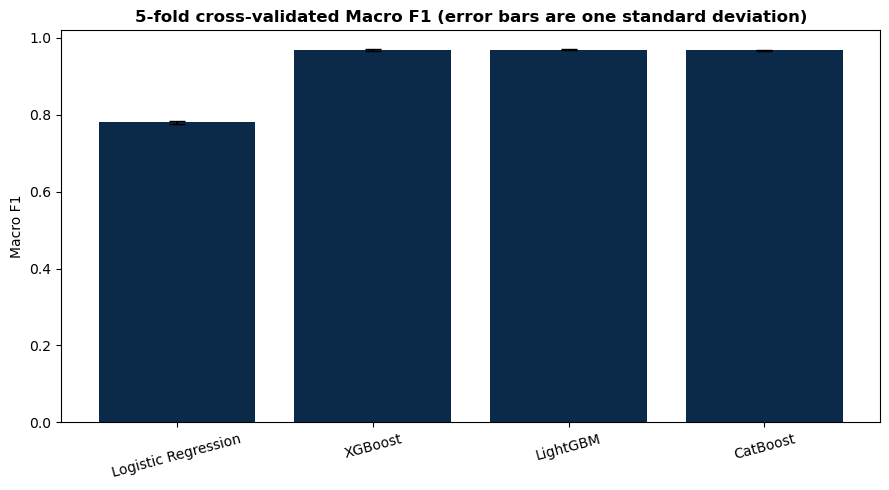

In [14]:
display(pd.DataFrame(cv_results).T.round(4))

figure, axes = plt.subplots(figsize=(9, 5))
names = list(cv_results)
means = [cv_results[n]["macro_f1_mean"] for n in names]
stds = [cv_results[n]["macro_f1_std"] for n in names]
axes.bar(names, means, yerr=stds, capsize=6, color="#0B2A4A")
axes.set_ylabel("Macro F1")
axes.set_title(f"{CV_FOLDS}-fold cross-validated Macro F1 (error bars are one standard deviation)",
               fontweight="bold")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 9. Model selection

The rule is applied to the validation results. No test-split number is consulted here.

In [15]:
# --------------------------------------------------------------- 7. selection
log("Selecting the final model")
ranked = sorted(
    candidates.items(),
    key=lambda kv: (
        round(kv[1]["validation"]["macro_f1"], 4),
        round(kv[1]["validation"]["per_class"]["High"]["recall"], 4),
        -abs(kv[1]["gaps"]["train_minus_val_macro_f1"]),
    ),
    reverse=True,
)
FINAL_NAME = ranked[0][0]
final_model = fitted[FINAL_NAME]

results["selection"] = {
    "rule": (
        "Rank candidates by validation Macro F1 rounded to four decimals; break ties on validation "
        "High-class recall and then on the smaller absolute train-validation Macro F1 gap. "
        "Cross-validation standard deviations are reported alongside so a reader can judge whether the "
        "winning margin exceeds run-to-run noise."
    ),
    "ranking": [
        {
            "model": name,
            "validation_macro_f1": entry["validation"]["macro_f1"],
            "validation_accuracy": entry["validation"]["accuracy"],
            "validation_high_recall": entry["validation"]["per_class"]["High"]["recall"],
            "validation_high_f1": entry["validation"]["per_class"]["High"]["f1"],
            "train_minus_val_macro_f1": entry["gaps"]["train_minus_val_macro_f1"],
            "cv_macro_f1_mean": cv_results[name]["macro_f1_mean"],
            "cv_macro_f1_std": cv_results[name]["macro_f1_std"],
        }
        for name, entry in ranked
    ],
    "final_model": FINAL_NAME,
    "margin_over_runner_up": (
        ranked[0][1]["validation"]["macro_f1"] - ranked[1][1]["validation"]["macro_f1"]
    ),
}
log(f"Final model: {FINAL_NAME}")

[20:31:49] Selecting the final model


[20:31:49] Final model: CatBoost


In [16]:
display(pd.DataFrame(results["selection"]["ranking"]).round(4))
print("Selection rule:", results["selection"]["rule"])
print("Final model:", FINAL_NAME)
print("Margin over the runner-up:", round(results["selection"]["margin_over_runner_up"], 5))

,model,validation_macro_f1,validation_accuracy,validation_high_recall,validation_high_f1,train_minus_val_macro_f1,cv_macro_f1_mean,cv_macro_f1_std
0,CatBoost,0.9706,0.9849,0.9191,0.9413,0.0126,0.9680,0.0012
1,LightGBM,0.9704,0.9844,0.9184,0.9419,0.0235,0.9691,0.0019
2,XGBoost,0.9703,0.9848,0.9156,0.9408,0.0183,0.9681,0.0020
3,Logistic Regression,0.7796,0.8602,0.8248,0.6168,0.0763,0.7805,0.0045


Selection rule: Rank candidates by validation Macro F1 rounded to four decimals; break ties on validation High-class recall and then on the smaller absolute train-validation Macro F1 gap. Cross-validation standard deviations are reported alongside so a reader can judge whether the winning margin exceeds run-to-run noise.
Final model: CatBoost
Margin over the runner-up: 0.00014


### Where the High-class decision threshold could be moved

The deployed model uses the ordinary rule: predict whichever class has the highest probability.
This table shows, on the **validation** split, what would happen if a farm preferred to catch
more High-need fields at the cost of more false alarms. It is documentation of the available
operating points, not a change to the deployed model, and it is deliberately computed on
validation rather than on test.

In [17]:
# ------------------------- 7b. High-class threshold study, tuned on validation only
val_proba_final = final_model.predict_proba(Xt_val)
threshold_rows = []
for t in [0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80]:
    masked = val_proba_final.copy()
    forced = masked[:, HIGH_INDEX] >= t
    alt = masked.copy()
    alt[:, HIGH_INDEX] = -1
    pred = np.where(forced, HIGH_INDEX, alt.argmax(axis=1))
    p, r, f, _ = precision_recall_fscore_support(
        y_val.values, pred, labels=[HIGH_INDEX], zero_division=0
    )
    threshold_rows.append(
        {
            "threshold": t,
            "high_precision": float(p[0]),
            "high_recall": float(r[0]),
            "high_f1": float(f[0]),
            "macro_f1": float(f1_score(y_val.values, pred, average="macro")),
            "accuracy": float(accuracy_score(y_val.values, pred)),
        }
    )

results["high_class_threshold_study"] = {
    "note": (
        "computed on the validation split only; the deployed model keeps the default argmax rule, so "
        "this table documents the operating points available if a farm wanted to trade precision for recall"
    ),
    "rows": threshold_rows,
}

,threshold,high_precision,high_recall,high_f1,macro_f1,accuracy
0,0.2,0.9186,0.9378,0.9281,0.9657,0.9839
1,0.3,0.9483,0.9308,0.9395,0.9699,0.9847
2,0.4,0.9595,0.9248,0.9418,0.9707,0.9849
3,0.5,0.9647,0.9191,0.9413,0.9706,0.9849
4,0.6,0.9693,0.9111,0.9393,0.9699,0.9848
5,0.7,0.9730,0.9042,0.9373,0.9692,0.9847
6,0.8,0.9795,0.8943,0.9350,0.9683,0.9846


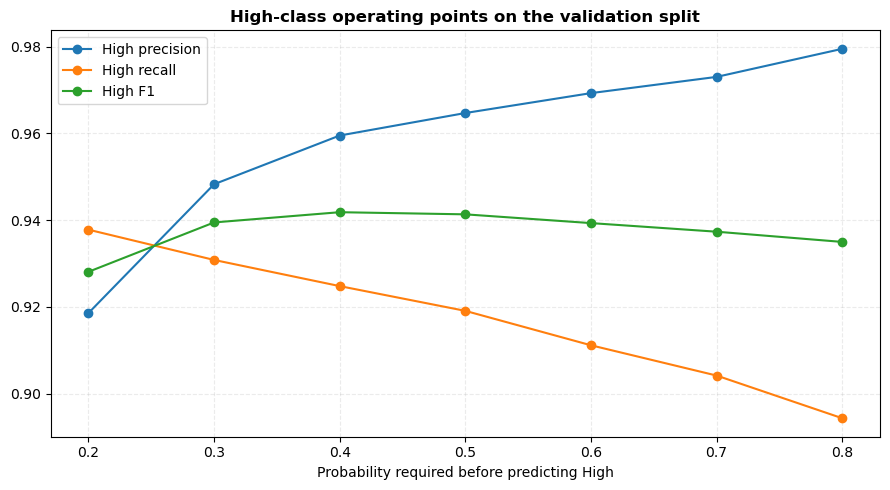

In [18]:
display(pd.DataFrame(threshold_rows).round(4))

figure, axes = plt.subplots(figsize=(9, 5))
frame = pd.DataFrame(threshold_rows)
axes.plot(frame["threshold"], frame["high_precision"], marker="o", label="High precision")
axes.plot(frame["threshold"], frame["high_recall"], marker="o", label="High recall")
axes.plot(frame["threshold"], frame["high_f1"], marker="o", label="High F1")
axes.set_xlabel("Probability required before predicting High")
axes.set_title("High-class operating points on the validation split", fontweight="bold")
axes.grid(alpha=0.25, ls="--")
axes.legend()
plt.tight_layout()
plt.show()

## 10. Final evaluation on the untouched test split

This is the only time the test split is used. Every decision above was already fixed.

In [19]:
# --------------------------------------------------------------- 8. final test
log("Single final evaluation on the untouched test split")
test_pred = final_model.predict(Xt_test).ravel()
test_proba = final_model.predict_proba(Xt_test)
test_metrics = evaluate(y_test.values, test_pred, test_proba, CLASSES)
results["final_test"] = test_metrics
results["test_set_classification_report"] = classification_report(
    y_test.values, test_pred, target_names=CLASSES, digits=4, zero_division=0
)
log(
    f"  test acc={test_metrics['accuracy']:.4f} macroF1={test_metrics['macro_f1']:.4f} "
    f"HighF1={test_metrics['per_class']['High']['f1']:.4f}"
)

# test-set metrics for every candidate, reported for transparency only; the model was
# already chosen from validation before any of these numbers existed
results["all_candidates_test"] = {
    name: evaluate(y_test.values, model.predict(Xt_test).ravel(), model.predict_proba(Xt_test), CLASSES)
    for name, model in fitted.items()
}

results["overfitting"] = {
    "final_model": FINAL_NAME,
    "train": {
        "accuracy": candidates[FINAL_NAME]["train"]["accuracy"],
        "macro_f1": candidates[FINAL_NAME]["train"]["macro_f1"],
    },
    "validation": {
        "accuracy": candidates[FINAL_NAME]["validation"]["accuracy"],
        "macro_f1": candidates[FINAL_NAME]["validation"]["macro_f1"],
    },
    "test": {"accuracy": test_metrics["accuracy"], "macro_f1": test_metrics["macro_f1"]},
    "gaps": {
        "train_minus_val_accuracy": candidates[FINAL_NAME]["train"]["accuracy"] - candidates[FINAL_NAME]["validation"]["accuracy"],
        "train_minus_test_accuracy": candidates[FINAL_NAME]["train"]["accuracy"] - test_metrics["accuracy"],
        "val_minus_test_accuracy": candidates[FINAL_NAME]["validation"]["accuracy"] - test_metrics["accuracy"],
        "train_minus_val_macro_f1": candidates[FINAL_NAME]["train"]["macro_f1"] - candidates[FINAL_NAME]["validation"]["macro_f1"],
        "train_minus_test_macro_f1": candidates[FINAL_NAME]["train"]["macro_f1"] - test_metrics["macro_f1"],
        "val_minus_test_macro_f1": candidates[FINAL_NAME]["validation"]["macro_f1"] - test_metrics["macro_f1"],
    },
    "controls_applied": [
        "early stopping against an inner split carved out of the training data, keeping validation free for selection",
        "shrinkage learning rate of 0.05",
        "row and column subsampling",
        "L1 and L2 penalties plus minimum-child-weight constraints",
        "bounded tree depth or leaf count",
        f"{CV_FOLDS}-fold stratified cross-validation to measure fold-to-fold variance",
    ],
}

[20:31:49] Single final evaluation on the untouched test split


[20:31:49]   test acc=0.9855 macroF1=0.9709 HighF1=0.9409


              precision    recall  f1-score   support

        High     0.9606    0.9219    0.9409      3151
         Low     0.9868    0.9952    0.9910     55488
      Medium     0.9856    0.9760    0.9808     35861

    accuracy                         0.9855     94500
   macro avg     0.9777    0.9644    0.9709     94500
weighted avg     0.9855    0.9855    0.9855     94500



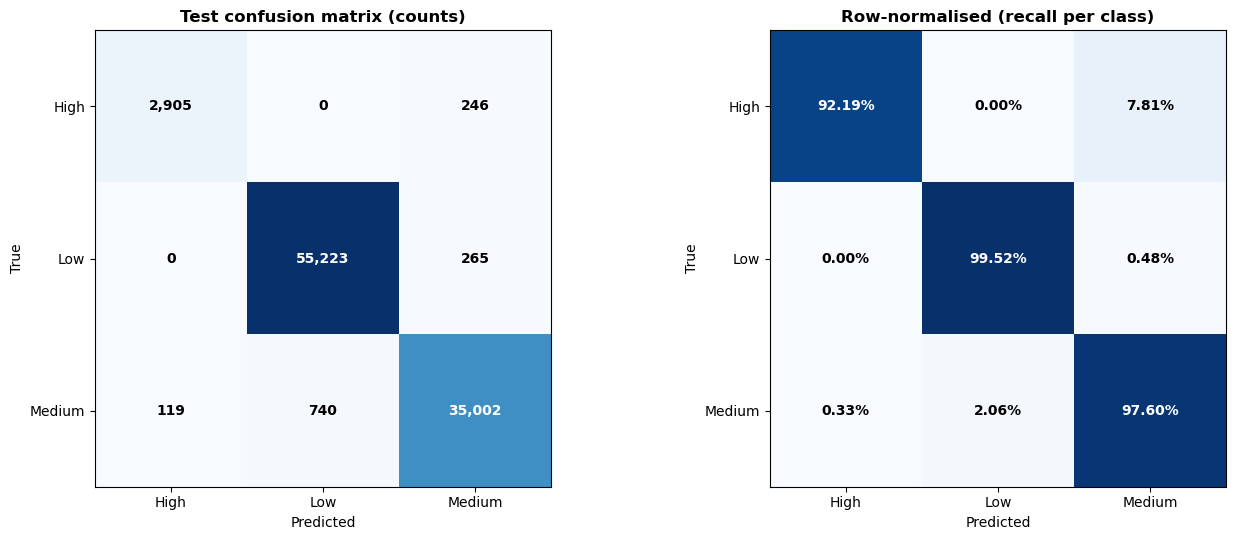

,test Macro F1,test accuracy,test High recall,test High F1,test Macro ROC-AUC
Logistic Regression,0.7848,0.8631,0.8334,0.6268,0.9618
XGBoost,0.9708,0.9855,0.9207,0.9407,0.9976
LightGBM,0.9704,0.9851,0.9210,0.9402,0.9976
CatBoost,0.9709,0.9855,0.9219,0.9409,0.9973


In [20]:
print(results["test_set_classification_report"])

matrix = np.array(test_metrics["confusion_matrix"])
figure, axes = plt.subplots(1, 2, figsize=(14, 5.5))

im = axes[0].imshow(matrix, cmap="Blues")
for i in range(len(CLASSES)):
    for j in range(len(CLASSES)):
        axes[0].text(j, i, f"{matrix[i, j]:,}", ha="center", va="center",
                     color="white" if matrix[i, j] > matrix.max() / 2 else "black",
                     fontweight="bold")
axes[0].set_xticks(range(len(CLASSES)), CLASSES)
axes[0].set_yticks(range(len(CLASSES)), CLASSES)
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")
axes[0].set_title("Test confusion matrix (counts)", fontweight="bold")

normalised = matrix / matrix.sum(axis=1, keepdims=True)
im = axes[1].imshow(normalised, cmap="Blues", vmin=0, vmax=1)
for i in range(len(CLASSES)):
    for j in range(len(CLASSES)):
        axes[1].text(j, i, f"{normalised[i, j]*100:.2f}%", ha="center", va="center",
                     color="white" if normalised[i, j] > 0.5 else "black", fontweight="bold")
axes[1].set_xticks(range(len(CLASSES)), CLASSES)
axes[1].set_yticks(range(len(CLASSES)), CLASSES)
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")
axes[1].set_title("Row-normalised (recall per class)", fontweight="bold")

plt.tight_layout()
plt.show()

display(pd.DataFrame({
    name: {
        "test Macro F1": round(m["macro_f1"], 4),
        "test accuracy": round(m["accuracy"], 4),
        "test High recall": round(m["per_class"]["High"]["recall"], 4),
        "test High F1": round(m["per_class"]["High"]["f1"], 4),
        "test Macro ROC-AUC": round(m["macro_roc_auc"], 4),
    }
    for name, m in results["all_candidates_test"].items()
}).T)

## 11. Overfitting analysis

An overfitted model is one that memorised its training rows. The evidence for or against that
is the size of the drop from training to validation to test, not the height of the test score.

,accuracy,macro_f1
Training,0.9843,0.9831
Validation,0.9849,0.9706
Test,0.9855,0.9709



Gaps:
  train_minus_val_accuracy         -0.0005
  train_minus_test_accuracy        -0.0012
  val_minus_test_accuracy          -0.0006
  train_minus_val_macro_f1         +0.0126
  train_minus_test_macro_f1        +0.0123
  val_minus_test_macro_f1          -0.0003

Controls applied:
  - early stopping against an inner split carved out of the training data, keeping validation free for selection
  - shrinkage learning rate of 0.05
  - row and column subsampling
  - L1 and L2 penalties plus minimum-child-weight constraints
  - bounded tree depth or leaf count
  - 5-fold stratified cross-validation to measure fold-to-fold variance


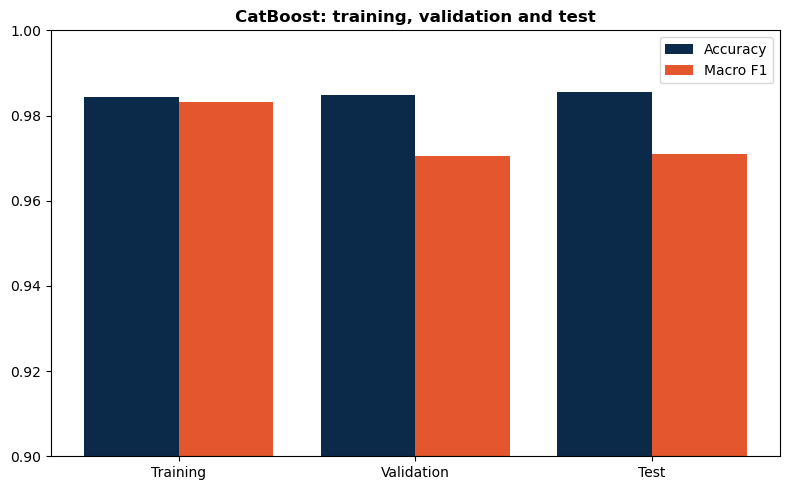

In [21]:
gaps = results["overfitting"]
display(pd.DataFrame({
    "Training": gaps["train"],
    "Validation": gaps["validation"],
    "Test": gaps["test"],
}).T.round(4))

print("\nGaps:")
for name, value in gaps["gaps"].items():
    print(f"  {name:<32} {value:+.4f}")

print("\nControls applied:")
for control in gaps["controls_applied"]:
    print(f"  - {control}")

figure, axes = plt.subplots(figsize=(8, 5))
splits = ["Training", "Validation", "Test"]
accuracy = [gaps["train"]["accuracy"], gaps["validation"]["accuracy"], gaps["test"]["accuracy"]]
macro_f1 = [gaps["train"]["macro_f1"], gaps["validation"]["macro_f1"], gaps["test"]["macro_f1"]]
positions = np.arange(3)
axes.bar(positions - 0.2, accuracy, 0.4, label="Accuracy", color="#0B2A4A")
axes.bar(positions + 0.2, macro_f1, 0.4, label="Macro F1", color="#E4572E")
axes.set_xticks(positions, splits)
axes.set_ylim(0.9, 1.0)
axes.set_title(f"{FINAL_NAME}: training, validation and test", fontweight="bold")
axes.legend()
plt.tight_layout()
plt.show()

## 12. Feature importance

Which inputs the final model relies on. Importances are read from the fitted model, normalised
to sum to one.

In [22]:
# --------------------------------------------------------------- 9. importance
if hasattr(final_model, "feature_importances_"):
    importances = np.asarray(final_model.feature_importances_, dtype=float)
    total = importances.sum() or 1.0
    results["feature_importance"] = {
        name: float(value)
        for name, value in sorted(
            zip(FEATURE_NAMES, importances / total), key=lambda kv: kv[1], reverse=True
        )
    }

,importance
Soil_Moisture,0.235099
Crop_Growth_Stage_Harvest,0.132842
Crop_Growth_Stage_Sowing,0.116293
Mulching_Used_Yes,0.105195
Temperature_C,0.101917
Wind_Speed_kmh,0.093894
Rainfall_mm,0.070709
Crop_Growth_Stage_Vegetative,0.013698
Humidity,0.012430
Water_Source_River,0.010172


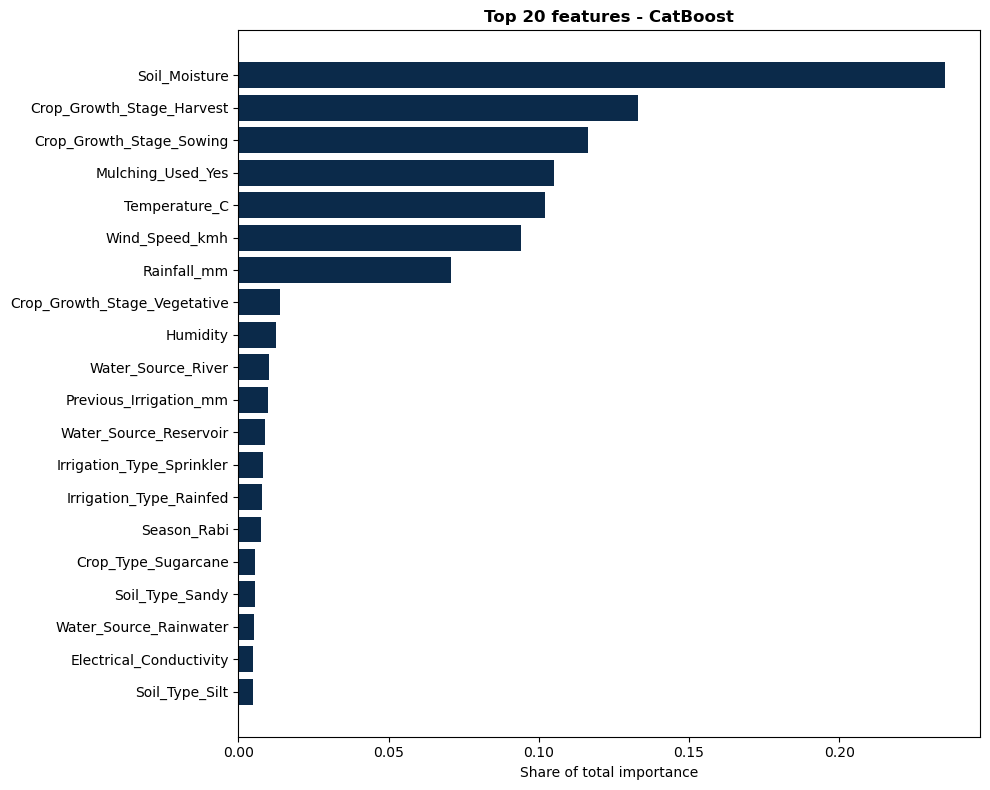

In [23]:
top = pd.Series(results["feature_importance"]).head(20)
display(top.round(6).to_frame("importance"))

figure, axes = plt.subplots(figsize=(10, 8))
axes.barh(top.index[::-1], top.values[::-1], color="#0B2A4A")
axes.set_xlabel("Share of total importance")
axes.set_title(f"Top 20 features - {FINAL_NAME}", fontweight="bold")
plt.tight_layout()
plt.show()

## 13. Saving the deployment artifacts

The encoder and the classifier are saved together as one pipeline object. The Flask application
therefore receives a row of raw field values and the artifact applies exactly the encoding it
was fitted with, which is what removes any chance of train-serving skew.

Before saving, the pipeline is asked to reproduce the predictions that were just scored. If it
disagreed on a single row, the assertion would stop the notebook here.

In [24]:
# --------------------------------------------------------------- 10. artifacts
log("Saving deployment artifacts")
deployment_pipeline = Pipeline([("preprocessor", tree_preprocessor), ("model", final_model)])
sanity = np.asarray(deployment_pipeline.predict(X_test.head(500))).ravel()
assert np.array_equal(sanity, test_pred[:500]), "pipeline output diverges from the evaluated model"

joblib.dump(deployment_pipeline, os.path.join(BASE_DIR, "irrigation_model.pkl"))

schema = {
    "final_model": FINAL_NAME,
    "target": TARGET,
    "class_labels": CLASSES,
    "class_index_to_label": {str(i): c for i, c in enumerate(CLASSES)},
    "raw_feature_order": X_raw.columns.tolist(),
    "categorical_features": CATEGORICAL,
    "numeric_features": NUMERIC,
    "categorical_levels": results["dataset"]["categorical_levels"],
    "numeric_ranges": results["dataset"]["numeric_ranges"],
    "encoded_feature_names": FEATURE_NAMES,
    "imbalance_strategy": BEST_STRATEGY,
    "random_seed": SEED,
    "training_rows": int(len(X_train)),
}
with open(os.path.join(BASE_DIR, "model_schema.json"), "w") as handle:
    json.dump(schema, handle, indent=2)

import sklearn  # noqa: E402
import xgboost  # noqa: E402
import lightgbm  # noqa: E402
import catboost  # noqa: E402
import imblearn  # noqa: E402
import sys  # noqa: E402

results["artifacts"] = {
    "irrigation_model.pkl": "sklearn Pipeline holding the training-fitted ColumnTransformer and the selected classifier",
    "model_schema.json": "raw feature order, categorical levels, numeric ranges and class mapping used by the API and the form",
    "model_metrics.json": "compact metrics file consumed by the Flask application",
    "experiments/results.json": "the complete experiment record behind every number in the documentation",
}
results["environment"] = {
    "python": sys.version.split()[0],
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "scikit-learn": sklearn.__version__,
    "xgboost": xgboost.__version__,
    "lightgbm": lightgbm.__version__,
    "catboost": catboost.__version__,
    "imbalanced-learn": imblearn.__version__,
    "joblib": joblib.__version__,
}

with open(os.path.join(OUT_DIR, "results.json"), "w") as handle:
    json.dump(results, handle, indent=2)

log("Done")

[20:31:56] Saving deployment artifacts


[20:31:56] Done


In [25]:
print("Final model :", schema["final_model"])
print("Artifact    :", os.path.join(BASE_DIR, "irrigation_model.pkl"))
print("Schema      :", os.path.join(BASE_DIR, "model_schema.json"))
print("Results     :", os.path.join(OUT_DIR, "results.json"))
print("\nTest accuracy :", round(results["final_test"]["accuracy"], 4))
print("Test Macro F1 :", round(results["final_test"]["macro_f1"], 4))
print("Test High F1  :", round(results["final_test"]["per_class"]["High"]["f1"], 4))

Final model : CatBoost
Artifact    : /Users/thekumarsai/Developer/smart-farm-flask/irrigation_model.pkl
Schema      : /Users/thekumarsai/Developer/smart-farm-flask/model_schema.json
Results     : /Users/thekumarsai/Developer/smart-farm-flask/experiments/results.json

Test accuracy : 0.9855
Test Macro F1 : 0.9709
Test High F1  : 0.9409


## 14. Serving the model

With the artifacts in place, start the API:

```bash
python app.py
```

or, the way it runs in production:

```bash
gunicorn app:app
```

`app.py` loads `irrigation_model.pkl`, `model_schema.json` and `experiments/results.json`. Every
metric the web interface displays is read from that results file, so the site cannot show a
number this notebook did not produce.